In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import quantem as em
import geometric_phase_analysis_2D as gpa2D

In [15]:
def gauss_2D_r(
        rr,
        s,
        A,
        B,
):

    gaussian_2d = A * np.exp(-((rr)**2/(2*s**2))) + B
    return gaussian_2d

(-0.5, 511.5, 511.5, -0.5)

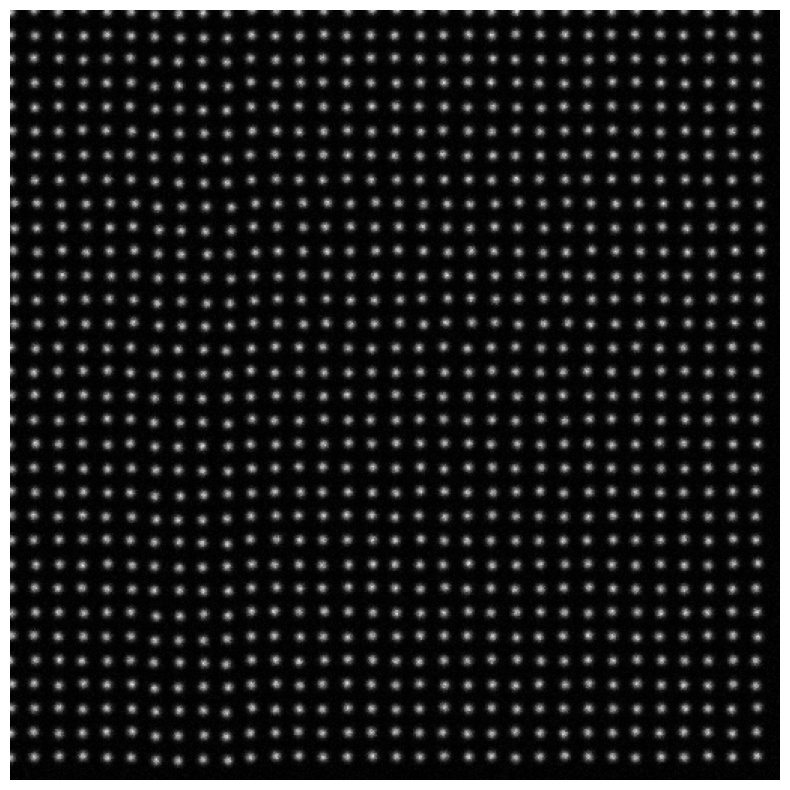

In [41]:
H, W = 512, 512
x = np.arange(0,H)
[xx,yy] = np.meshgrid(x,x)
im = np.zeros(xx.shape)

nSites_row = H//14
nSites_col = W//14
r = 2

a_rows = 16
a_cols = 16
coords = gpa2D.create_lattice(nSites_row,nSites_col,a_rows,a_cols)
nAtoms = coords.shape[0]

# Vertical shift
coords[288:501,1] = coords[288:501,1] + 2

# Horizontal shift
for i in range(6, 1280, 36):
    coords[i,0] = coords[i,0] + 2
for i in range(7, 1280, 36):
    coords[i,0] = coords[i,0] + 2
for i in range(8, 1280, 36):
    coords[i,0] = coords[i,0] + 2
for i in range(9, 1280, 36):
    coords[i,0] = coords[i,0] + 2

valid_mask = (
    (coords[:, 0] >= 0) & (coords[:, 0] < W) &
    (coords[:, 1] >= 0) & (coords[:, 1] < H)
)
coords = coords[valid_mask]

ww = 20 #window width
half_width = int(ww//2)

x = np.arange(0, ww) - ww // 2
y = np.arange(0, ww) - ww // 2
xx, yy = np.meshgrid(x, y, indexing = 'ij')
sg = 2
r = 0


# Build simulated image by placing an error function at each coordinate
px, py = coords[:, 0], coords[:, 1]
u_norm = 16
disorder_multiplier = 0.1

for atom_index in range(px.shape[0]):
    a_x = px[atom_index] + (np.random.rand(1)[0]-0.5) * disorder_multiplier * u_norm 
    a_y = py[atom_index] + (np.random.rand(1)[0]-0.5) * disorder_multiplier * u_norm 

    a_x_residual = a_x - np.floor(a_x)
    a_x_floor = np.floor(a_x).astype(int)
    a_y_residual = a_y - np.floor(a_y)
    a_y_floor = np.floor(a_y).astype(int)

    xc = a_x_residual
    yc = a_y_residual

    rr = np.sqrt((xx - xc)**2 + (yy - yc) ** 2)

    sub_x0 = max(0, - (a_x_floor - half_width))
    sub_x1 = ww - max(0, (a_x_floor + half_width) - H)
    sub_y0 = max(0, - (a_y_floor - half_width))
    sub_y1 = ww - max(0, (a_y_floor + half_width) - W)

    # image index (in image coordinates)
    x1 = min(H, a_x_floor + half_width)
    y1 = min(W, a_y_floor + half_width)
    x0 = max(0, a_x_floor - half_width)
    y0 = max(0, a_y_floor - half_width)

    rr_v = rr[sub_x0:sub_x1, sub_y0:sub_y1]
    g = gauss_2D_r(rr_v, sg, 1, 0) /2
    g[rr_v<np.min(rr_v)/np.sqrt(2)] = 0
    g -= np.min(g)

    im[x0:x1, y0:y1] += g
nx = W
ny = W

add_noise = True
im_bg = 0.01
rescale = 100
im_max = np.max(im) + im_bg
noisy_im = np.random.poisson((im + im_bg) / im_max * rescale) * im_max / rescale # noisy image
im = noisy_im

plt.figure(figsize = (10,10))
plt.imshow(im, cmap = 'gray')
plt.axis('off')

phase containers 3


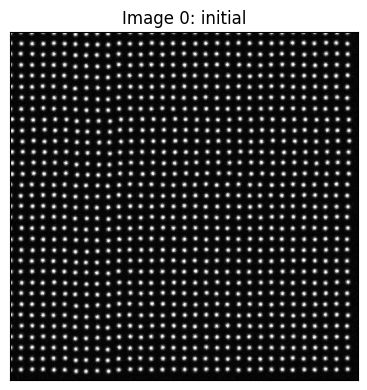

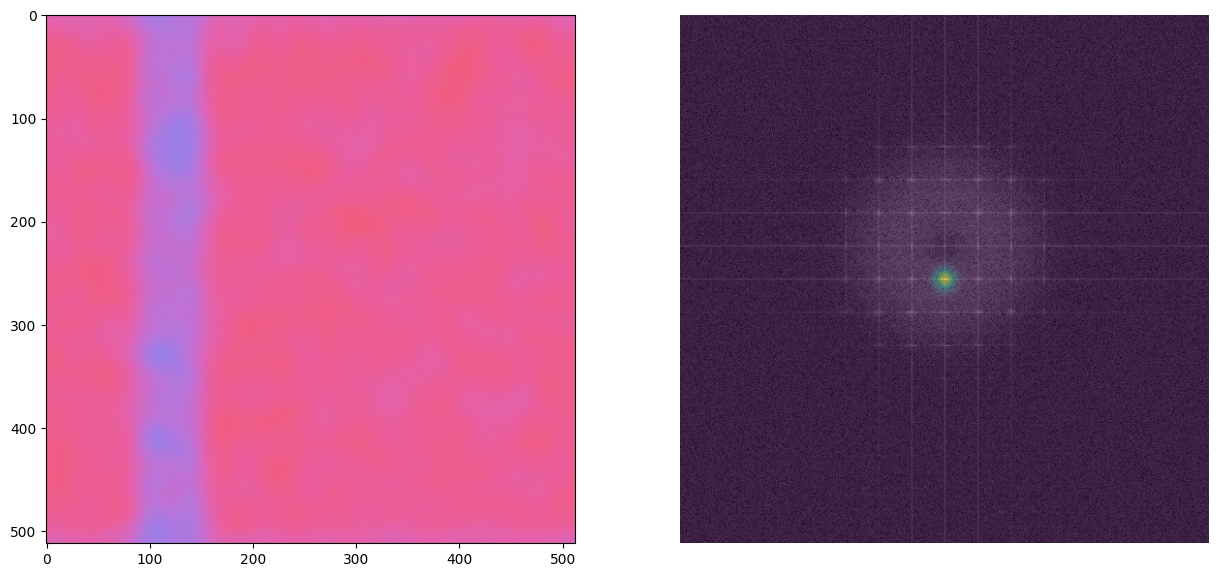

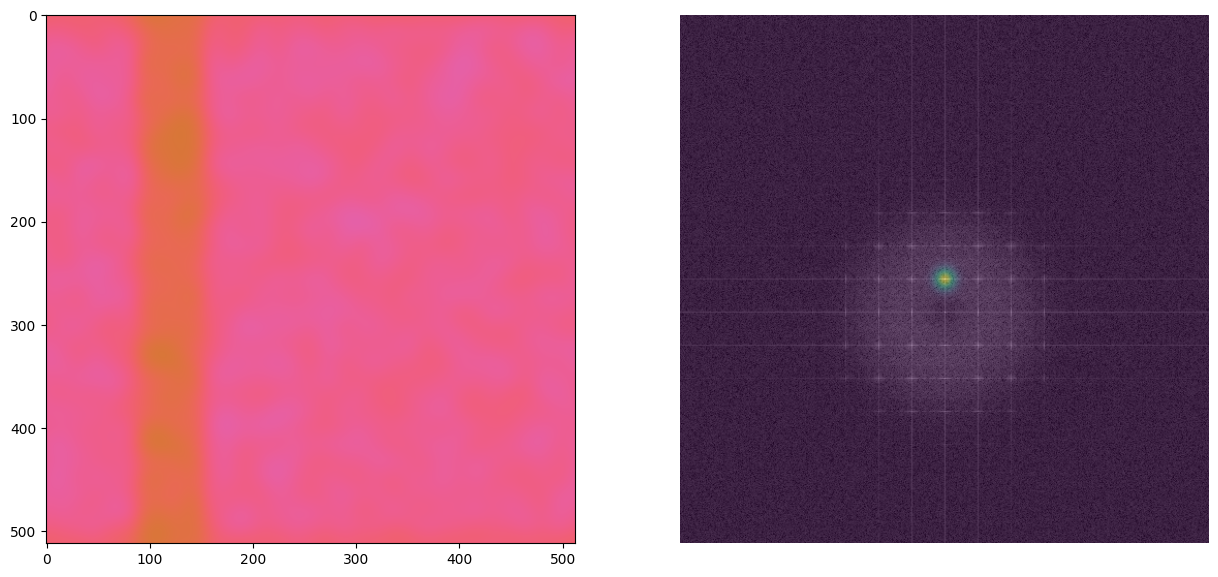

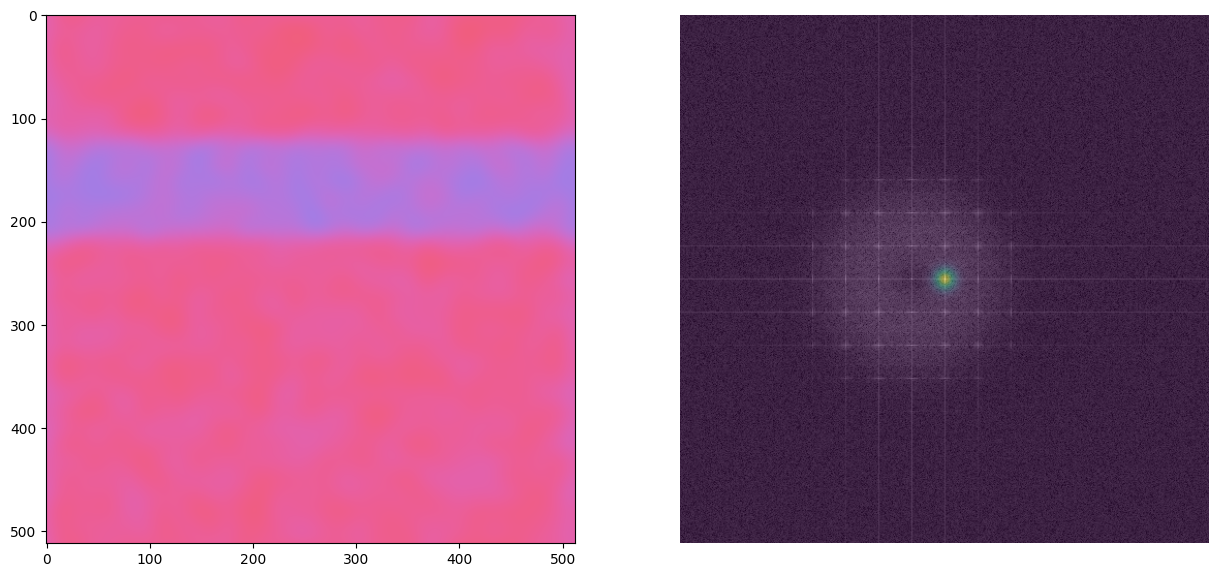

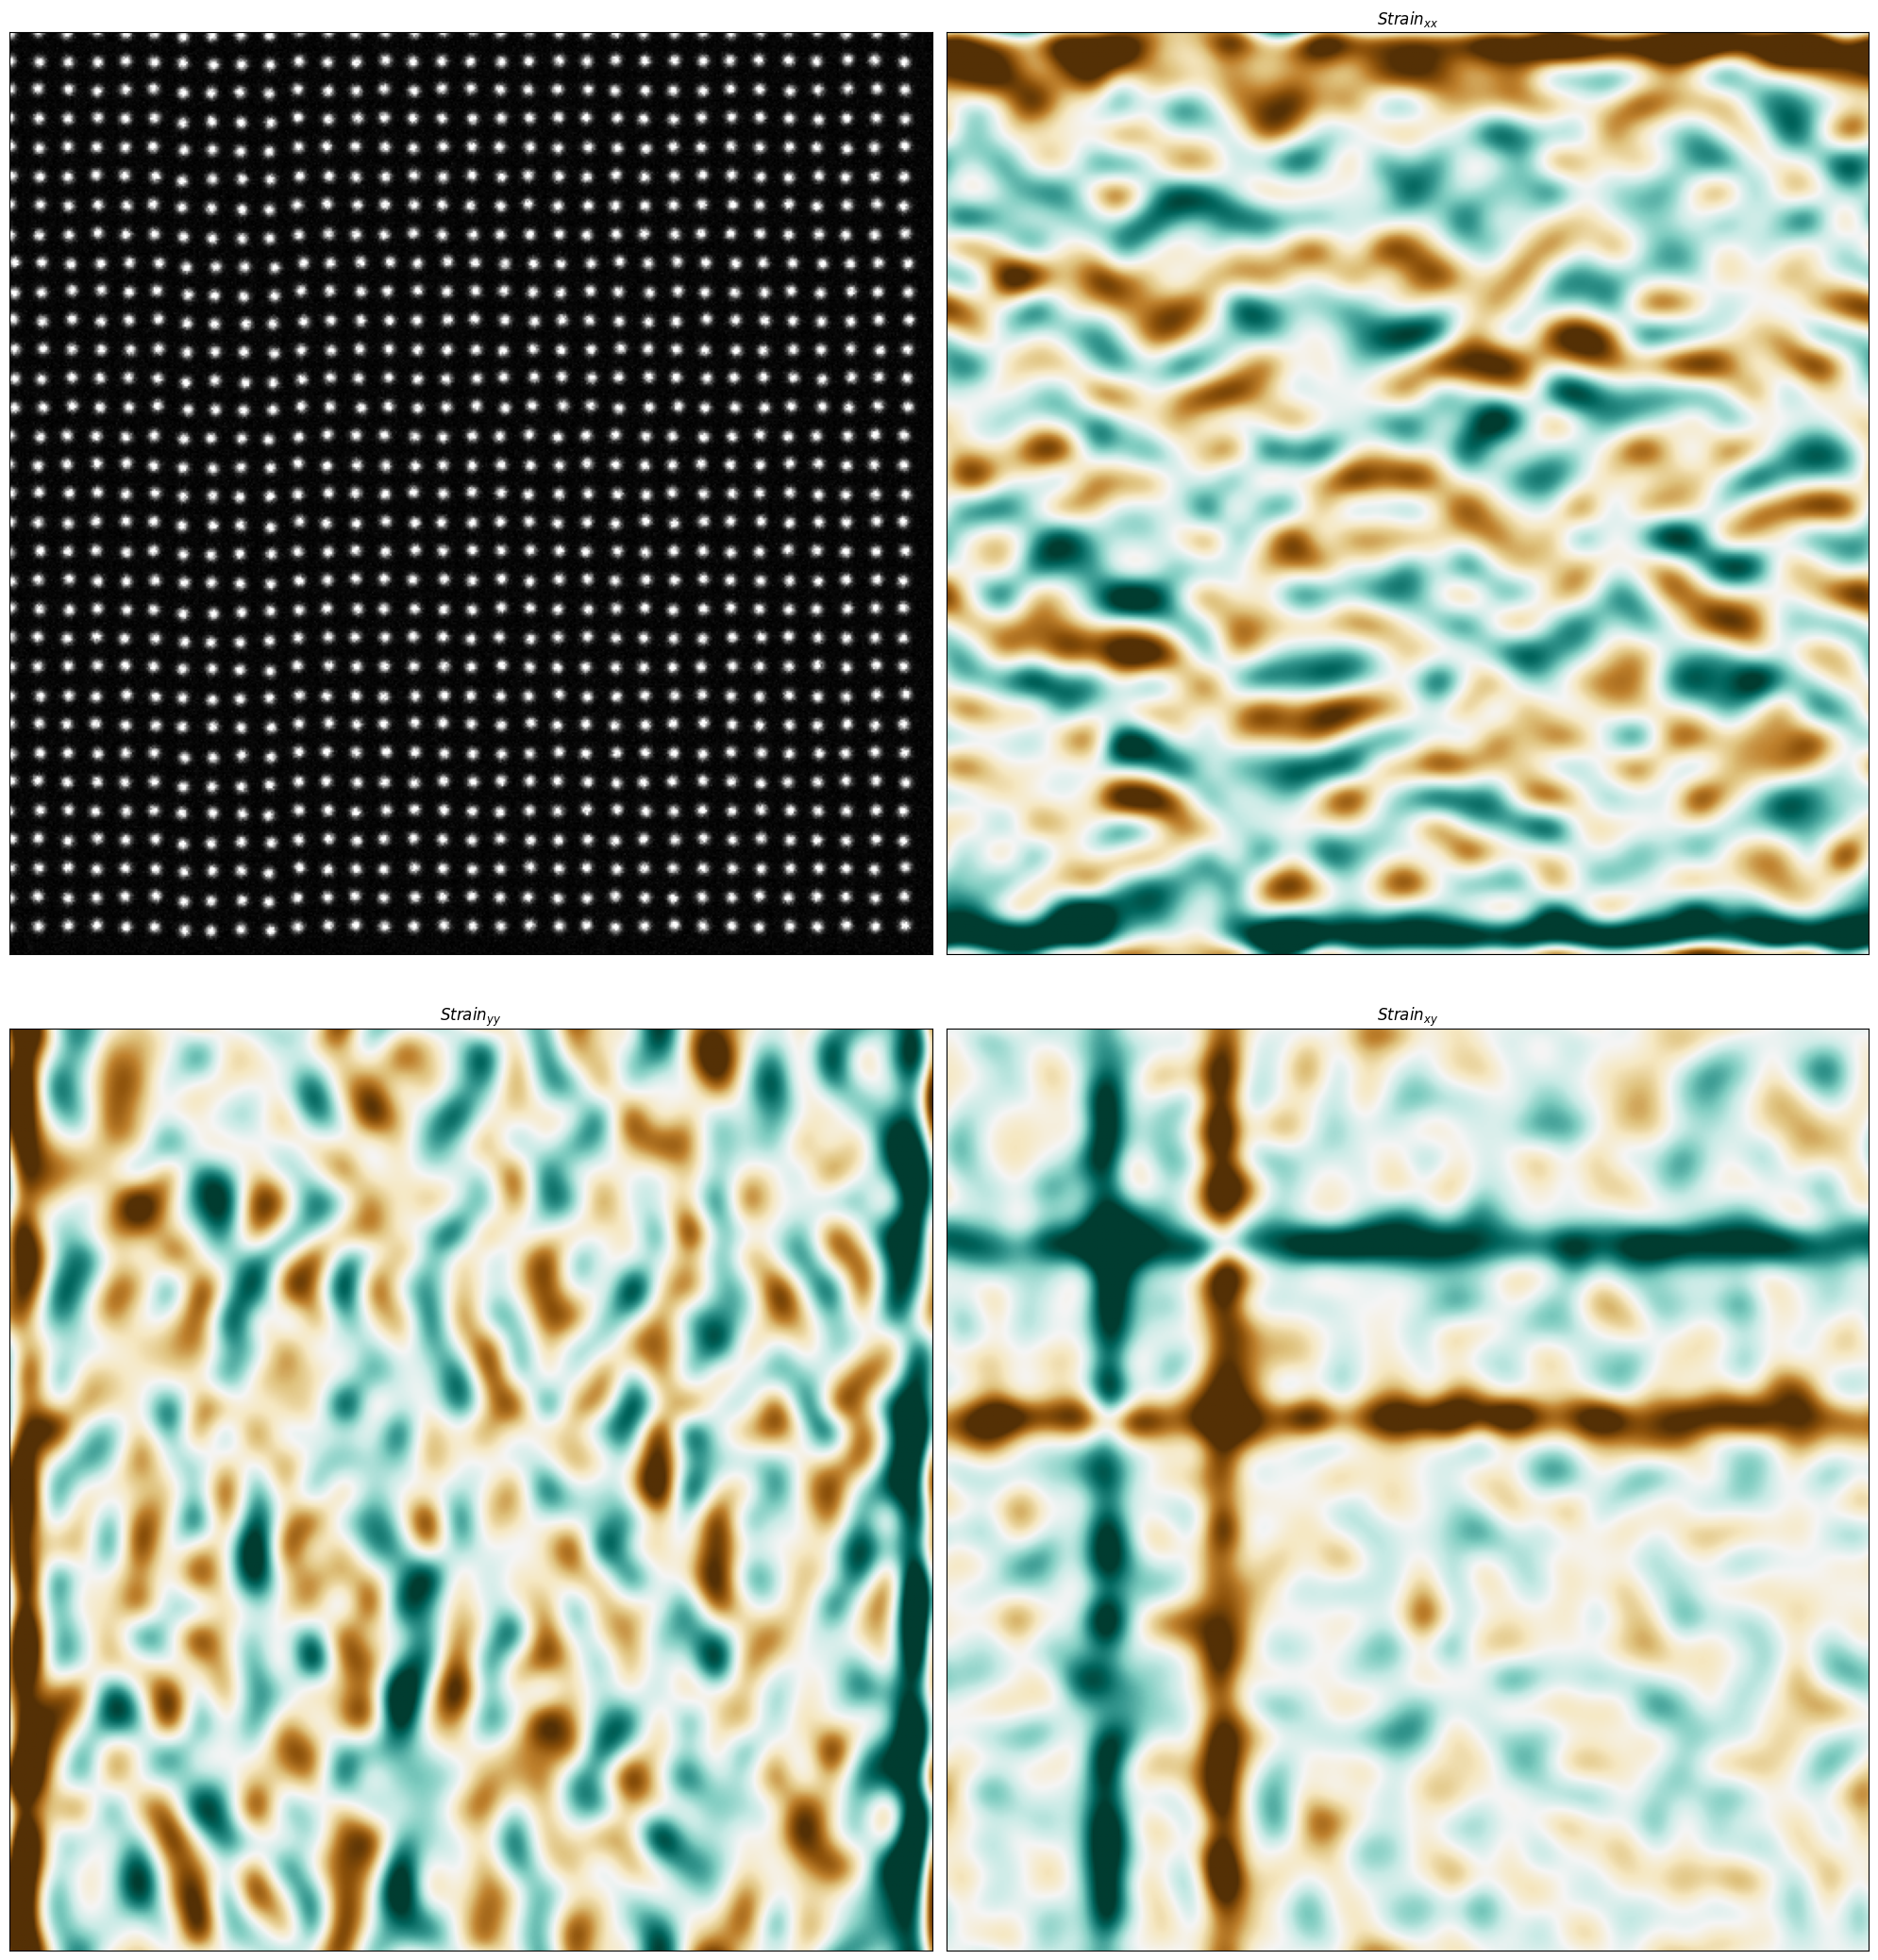

In [44]:
gpa_object = gpa2D.geometric_phase_analysis_2D.from_data(
    im,
    ).preprocess(
        pad_fraction = 0.25,
        pad_value = "median",
        show_images = True,
    ).define_diffraction_peaks(
        diffraction_peaks_dict = None,
        num_peaks_use = 3,
    ).calculate_phase_maps(
        np.mean(im.shape)/ 10,
    ).calculate_strain_map(
        num_peaks = 3,
    )